In [1]:
'''
    手写阿拉伯数字
'''
import tensorflow as tf
#加载数据,导入MNIST手写阿拉伯数字数据集
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

#特征缩放(0,1)区间
x_train,x_test=x_train/255.0,x_test/255.0
#建立模型
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #数据预处理层,将输入的多为数据展评成一维的向量。 输入层不需要单独审评
    tf.keras.layers.Dense(128,activation='relu'), #全连接层,具有128个神经元，激活函数为relu
    tf.keras.layers.Dropout(0.2), #随机丢弃20%的神经元,防止过拟合
    tf.keras.layers.Dense(10,activation='softmax') #输出层,10个神经元,激活函数为softmax
])

#设定模型参数,优化器、损失函数、效果衡量指标
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#模型训练
model.fit(x_train,y_train,epochs=5,validation_split=0.2)

#模型评估
model.evaluate(x_test,y_test)

E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8430 - loss: 0.5417 - val_accuracy: 0.9563 - val_loss: 0.1544
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9492 - loss: 0.1687 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9649 - loss: 0.1202 - val_accuracy: 0.9716 - val_loss: 0.0977
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9716 - loss: 0.0932 - val_accuracy: 0.9706 - val_loss: 0.0933
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9759 - loss: 0.0798 - val_accuracy: 0.9735 - val_loss: 0.0872
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9712 - loss: 0.0929


[0.07855238020420074, 0.9753999710083008]

In [2]:
'''
    机器学习流程十大步骤:
'''
#1.MNIST手写阿拉伯数字数据集
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
#训练/测试数据的X/y维度
# print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

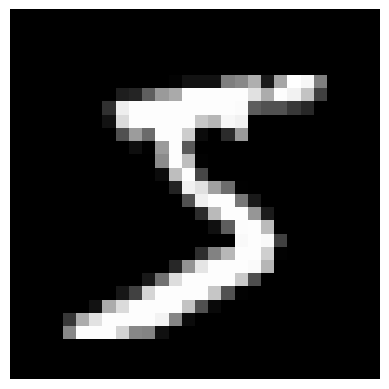

In [5]:
#2.EDA,对数据集进行探索与分析,首先观察训练数据的目标值(y),即影像的真实结果
##训练数据集前10张图片的数字
# print(y_train[:10])
##打印第一个训练数据的像素
print(x_train[0])

##可视化图片中手写的数字
###将非0的数字转为1,显示第一张图片
data = x_train[0].copy()
data[data > 0] = 1

###将转换后的二维内容展示出来,隐约是5
text_image = []
for i in range(data.shape[0]):
    text_image.append(''.join(str(data[i])))

print('\n'.join(text_image))

#显示第一个训练数据图像
import matplotlib.pyplot as plt

#第一批数据
X2 = x_train[0,:,:]
#绘制点阵图 cmap='gray'表示灰度图
plt.imshow(X2.reshape(28,28),cmap='gray')

#隐藏刻度
plt.axis('off')

#显示图形
plt.show()

In [16]:
#3.进行特征工程,将特征缩放到(0,1)区间,特征缩放可以提高模型准确度,并且可以加快收敛速度。特征缩量采用正态化公式
#正态化公式:X_norm = (X - X_min)/(X_max - X_min)
#颜色范围0-255,所以缩放公式为:X_norm = X/255
#颜色0为白色,与RGB颜色不同,(0,0,0)为黑色
# x_train_norm,x_test_norm=x_train/255.0,x_test/255.0
x_train_norm,x_test_norm=x_train,x_test
print(x_train_norm[0])

# 4,数据分割为训练数据和测试数据。加载MNIST数据集时,数据已经Been split into train and test sets.
# 5,建立模型结构,keras提供两类模型,包括顺序模型(Sequential Model)及Functional API模型。Functional API模型可以建立更复杂的模型,如多输入模型、多输出模型。
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), #数据预处理层,将输入的多为数据展评成一维的向量。 输入层不需要单独指定
    tf.keras.layers.Dense(128,activation='relu'), #完全连接层,具有128个神经元，激活函数为relu。128个神经元即128条回归线,每一条回归线有784个特征,输出通常定为4的倍数。
    tf.keras.layers.Dropout(0.2), #随机丢弃20%的神经元,防止过拟合。通常会在每一层Dense之后都是加一个Dropout层
    tf.keras.layers.Dense(10,activation='softmax') #输出层,也是一个完全连接层,10个神经元,激活函数为softmax。输出层通常定义为10个神经元,因为手写阿拉伯数字有10个数字,0-9。
])
# 6,模型编译,模型编译时,需要指定优化器、损失函数、效果衡量指标。优化器采用adam,损失函数采用sparse_categorical_crossentropy,效果衡量指标采用accuracy。
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',#损失函数为交叉熵,而非MSE
              metrics=['accuracy'])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6916 - loss: 8.4045 - val_accuracy: 0.8608 - val_loss: 0.5820
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8184 - loss: 0.6938 - val_accuracy: 0.9035 - val_loss: 0.4160
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8603 - loss: 0.5257 - val_accuracy: 0.9190 - val_loss: 0.3739
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8719 - loss: 0.4876 - val_accuracy: 0.9268 - val_loss: 0.3262
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8847 - loss: 0.4399 - val_accuracy: 0.9269 - val_loss: 0.3178


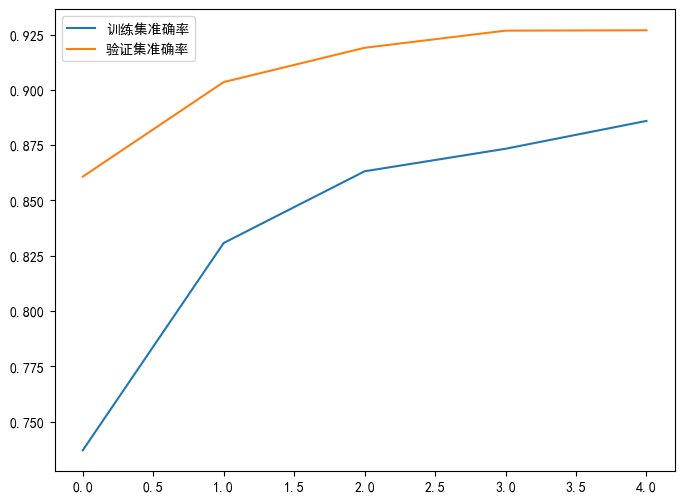

In [17]:
#7.步骤6: 结合训练数据及模型结构,进行模型训练
history = model.fit(x_train_norm,y_train,
                    epochs=5,#所有数据经过一次正向和反向传导,称之为一次执行周期。训练5个周期,即训练5个执行周期。
                    validation_split=0.2)
#对训练过程的准确绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'],label='训练集准确率')
plt.plot(history.history['val_accuracy'],label='验证集准确率')
plt.legend()

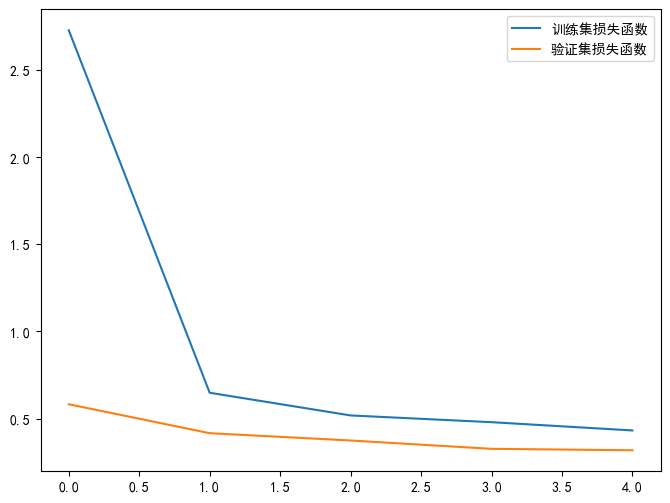

In [18]:
#训练过程中的损失函数图,如下图所示,随着执行周期次数的增加,损失越来越低,验证数据与训练数据的损失应趋于一致
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label='训练集损失函数')
plt.plot(history.history['val_loss'],label='验证集损失函数')
plt.legend()

In [19]:
import numpy as np

# 步骤7: 评分(Score Model),使用evaluate()函数,输入测试数据,会计算出损失及准确率
score = model.evaluate(x_test_norm,y_test,verbose=0)
for i,x in enumerate(score):
    print(f'{model.metrics_names[i]}:{score[i]:.4f}')

#实际对比测试数据的前20个,使用predict()函数,输入测试数据,会返回一个10个元素的向量,表示每个数字的概率。
# predictions = model.predict_classes(x_test_norm)
predictions = model.predict(x_test_norm)
predictions_classes = np.argmax(predictions,axis=1)
#
# #比对实际结果与预测结果
print('actual    :',y_test[0:20])
print('prediction:',predictions[0:20])


loss:0.3054
compile_metrics:0.9243
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction: [[4.88788505e-34 0.00000000e+00 4.64349496e-11 1.06950004e-09
  0.00000000e+00 7.12082414e-24 8.76512505e-29 1.00000000e+00
  3.00834333e-33 1.87604771e-12]
 [0.00000000e+00 3.06360380e-05 9.99969363e-01 2.54537752e-10
  0.00000000e+00 4.67530032e-38 4.59500907e-23 2.46894777e-25
  1.21048435e-31 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 1.30457060e-13 6.10118807e-22
  2.51979646e-17 2.61821220e-27 6.44357106e-15 5.38377946e-17
  2.74159321e-19 5.17233064e-20]
 [9.99997377e-01 0.00000000e+00 2.50469088e-06 3.98607987e-11
  0.00000000e+00 1.64987246e-10 1.11294263e-07 4.24091660e-08
  1.44495305e-09 3.65239892e-16]
 [1.14323105e-27 4.22486214e-21 2.68695839e-08 2.00476300e-14
  9.99999166e-01 1.98462433e-19 1.56043914e-10 4.38570125e-10
  6.45092179e-22 8.88492593e-07]
 [0.00000000e+00 1.00000000e+00 1.44921476e-14 1.22815948e-23
  4.3435185

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
0-9预测概率:[0.   0.   0.   0.   0.   0.57 0.43 0.   0.   0.  ]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1

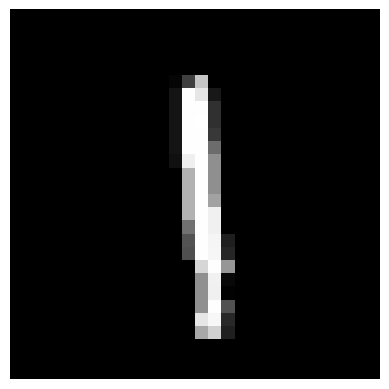

In [24]:
# 输出第9个的概率: 使用predict()函数,可以得到0-9预测概率各自的值
predictions = model.predict(x_test_norm[8:9])
print(f'0-9预测概率:{np.around(predictions[0],2)}')

data9 = x_test_norm[8:9]
data[data > 0] = 1
text_image = []

###将转换后的二维内容展示出来,隐约是5
text_image = []
for i in range(data.shape[0]):
    text_image.append(''.join(str(data[i])))

print('\n'.join(text_image))

#显示第一个训练数据图像
import matplotlib.pyplot as plt

#第一批数据
X2 = x_train[8,:,:]
#绘制点阵图 cmap='gray'表示灰度图
plt.imshow(X2.reshape(28,28),cmap='gray')

#隐藏刻度
plt.axis('off')

#显示图形
plt.show()

In [25]:
# 步骤8: 效果评估,暂不进行,后面通过调校相关超参数及模型结构,寻找最佳模型和参数。超参数是指在模型训练前可以调整的参数,如学习率、执行周期、权重初始值、训练批量等,但不含模型求算的参数如权重或偏差。
# 步骤9: 模型部署,将最佳模型存盘,再开发用户接口或提供API,连同模型文件一并部署到线上环境
## 模型存档
model.save('model.h5')
print("=====================")
print("模型已保存")

#模型载入
model = tf.keras.models.load_model('model.h5')



模型已保存


In [33]:
# 步骤10: 接收新数据预测
'''
    使用面板,绘制0~9,实际测试看
'''
from skimage import io
from skimage.transform import resize
import numpy as np

upload_file = "./digit_image/1.png"
image6 = io.imread(upload_file,as_gray=True)

#缩为(28,28)大小的影像
image_resized = resize(image6,(28,28),anti_aliasing=True)
X1 = image_resized.reshape(1,28,28)/255 #/255

#反转颜色,颜色0为白色,与RGB颜色不同,它的0为黑色
X1 = np.abs(1-X1)

#预测
# predictions = model.predict_classes(X1)
predictions = model.predict(X1)
print(predictions)

#使用下面指令显示模型汇总信息
model.summary()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0.105356   0.04584321 0.07874799 0.08562013 0.05608268 0.06865988
  0.05466897 0.04295632 0.34364977 0.1184151 ]]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,772 (397.55 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
'''
    绘制模型结构:
    1.安装graphviz软件,将安装目录下的bin加入到环境变量
    2.安装依赖库  pip install graphviz pydotplus
'''